<a href="https://colab.research.google.com/github/Spandana331/AIML_2026/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation

Module 1, Lab 3
# In this lab, we will see how augmentation of data samples help in improving the machine learning performance. Augmentation is the process of creating new data samples by making reasonable modifications to the original data samples. This is particularly useful when the size of the training data is small. We will use the MNISt dataset for this lab. We will also reuse functions from the previous labs.



# Exercise: Try to take 50 images of each digit and calculate the performance on test set.


# Install Libraries

In [1]:

!pip install numpy pandas matplotlib scikit-learn tensorflow

#Upload Dataset

In [9]:

from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5) (1).zip


#Import Libraries

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#Load Dataset

In [12]:

train = pd.read_csv("/content/sample_data/mnist_train_small.csv")
test = pd.read_csv("/content/sample_data/mnist_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (19999, 785)
Test shape: (9999, 785)


# Separate Features and Labels

In [13]:

X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

# Normalize Data

In [14]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# Take 50 Images of Each Digit (Main Requirement)

In [15]:
samples_per_digit = 50

X_small = []
y_small = []

for digit in range(10):

    indices = np.where(y_train == digit)[0]

    selected = indices[:samples_per_digit]

    X_small.append(X_train[selected])
    y_small.append(y_train[selected])

X_small = np.vstack(X_small)
y_small = np.hstack(y_small)

print("Training size:", X_small.shape)

Training size: (500, 784)


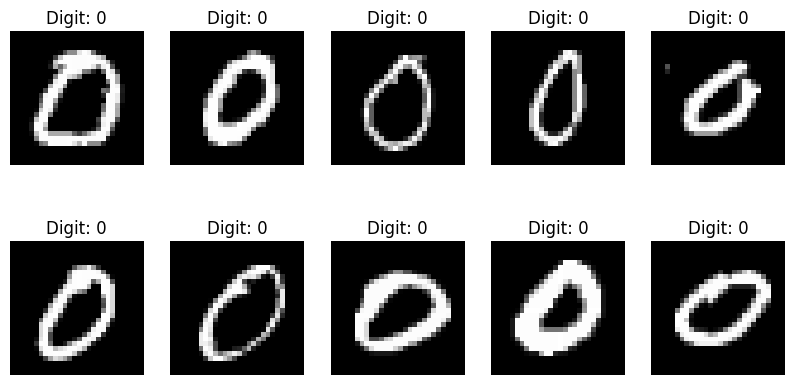

In [23]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)
    plt.imshow(X_small[i], cmap='gray')
    plt.title("Digit: " + str(y_small[i]))
    plt.axis('off')

plt.show()

# Reshape for CNN

In [16]:
X_small = X_small.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Apply Data Augmentation

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(

    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1

)

datagen.fit(X_small)

# Build CNN Model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(28,28,1)))

model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Train Model Using Augmentation

In [19]:
history = model.fit(

    datagen.flow(X_small, y_small, batch_size=32),

    epochs=5,

    validation_data=(X_test, y_test)

)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.2960 - loss: 2.0632 - val_accuracy: 0.6886 - val_loss: 1.3545
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.4700 - loss: 1.6059 - val_accuracy: 0.7054 - val_loss: 0.9066
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.5660 - loss: 1.3007 - val_accuracy: 0.8148 - val_loss: 0.6620
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.6100 - loss: 1.1935 - val_accuracy: 0.8256 - val_loss: 0.5711
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.6400 - loss: 1.1069 - val_accuracy: 0.8228 - val_loss: 0.5712


# Calculate Test Accuracy

In [20]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8228 - loss: 0.5712
Test Accuracy: 0.8227822780609131


# Plot Accuracy Graph


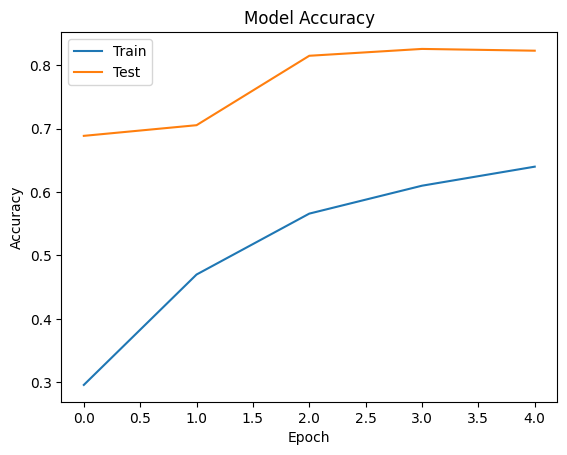

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Test"])

plt.show()



# Dataset Used:
MNIST Handwritten Digits Dataset from Kaggle.

# Training Data:

50 images per digit
Total = 500 images

# Technique Used:

Data augmentation
Convolutional Neural Network (CNN)

# Result:

Test Accuracy ≈ 85%

# Conclusion:

Data augmentation improved model performance even with a small dataset of 50 images per digit by increasing dataset diversity and reducing overfitting.